In [11]:
import sys
import os
import re
import json
import html
import random
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from transformers import pipeline
from tqdm.auto import tqdm
from datasets import load_dataset
from IPython.display import HTML, display

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits
from src.utils import (
    highlight_spans,
    make_json_serializable,
    predict_with_pipeline,
    trim_char_span,
)

In [12]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Dataset and model
DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

# Columns
TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"

# Class labels used by the Hugging Face classifier
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

# Inference settings
MAX_LENGTH = 512
BATCH_SIZE = 16
if torch.cuda.is_available():
    TORCH_DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    TORCH_DEVICE = torch.device("mps")
else:
    TORCH_DEVICE = torch.device("cpu")

DEVICE = TORCH_DEVICE

# Random baseline settings
SPAN_LENGTH_VALUES = [1, 3, 5, 10, 15, 20, 25]
ABLATION_MODES = ["mask"]

# Main baseline: one contiguous random span.
# Secondary baseline: randomly select a word budget and merge adjacent selected words.
SPAN_SELECTION_MODES = [
    "single_contiguous",
    "multi_word_budgeted",
]
MULTI_WORD_BUDGETED_MIN_LENGTH = 10
N_RANDOM_SAMPLES_PER_CONFIG = 5

# Config-search setup
CONFIG_SEARCH_SCOPE = "train_val_tp"
BEST_CONFIG_CONFUSION_TYPE = "TP"

# Output
BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "random_baseline_results_multi_mask"
PLOTS_DIR = OUTPUT_DIR / "plots"

BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Pipeline device:", DEVICE)
print("Torch device:", TORCH_DEVICE)

Pipeline device: mps
Torch device: mps


In [13]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
model = pipe.model
model.to(TORCH_DEVICE)
model.eval()

MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

print("Mask token:", MASK_TOKEN)
print("Model labels:", model.config.id2label)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Model labels: {0: 'LABEL_0', 1: 'LABEL_1'}


# Load prepared data

In [14]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

All: (2191, 30)
Train: (1533, 30)
Validation: (220, 30)
Test: (438, 30)
Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

# Build train+validation config-search set.

The config search is based only on true positives because these are the instances where the classifier predicts the document as inappropriate. The baseline should ideally identify spans whose perturbation reduces this score.

In [15]:
train_val_df = pd.concat(
    [train_df, val_df],
    ignore_index=True
)

train_tp_positions = train_df.index[
    train_df["confusion_type"] == "TP"
].tolist()

val_tp_positions = val_df.index[
    val_df["confusion_type"] == "TP"
].tolist()

train_val_tp_positions = train_val_df.index[
    train_val_df["confusion_type"] == "TP"
].tolist()

test_tp_positions = test_df.index[
    test_df["confusion_type"] == "TP"
].tolist()

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Train+Validation rows:", len(train_val_df))
print("Test rows:", len(test_df))

print("Train TP:", len(train_tp_positions))
print("Validation TP:", len(val_tp_positions))
print("Train+Validation TP:", len(train_val_tp_positions))
print("Test TP:", len(test_tp_positions))

Train rows: 1533
Validation rows: 220
Train+Validation rows: 1753
Test rows: 438
Train TP: 785
Validation TP: 88
Train+Validation TP: 873
Test TP: 186


# Random baseline span localization

This notebook evaluates a random span baseline for span-level localization of document-level inappropriateness predictions.

The baseline does not use attribution scores. Instead, it randomly selects spans and measures how much masking these spans changes the classifier's inappropriate-class probability.

The main score is:

```text
prob_drop = p_inappropriate_original - p_inappropriate_masked
```
A positive `prob_drop` means that masking the selected span decreases the classifier's predicted probability for the inappropriate class.

The baseline is evaluated in two phases:

Config search on train+validation true positives
All random configurations are applied to true-positive arguments from train and validation. Each configuration is sampled multiple times per argument.
Final application of the selected config
After inspecting summaries and plots, the selected configuration is applied to the test set. For completeness, it is also applied to all splits.

Two random span selection modes are considered:

- `single_contiguous`: selects one contiguous random word span.
- `multi_word_budgeted`: randomly selects a fixed number of words and merges adjacent words into spans. This mode is only evaluated for larger word budgets.

In [16]:
def get_tokenized_words(text, max_length=MAX_LENGTH):
    """
    Tokenize text and aggregate model subtokens to word-level units.
    
    The returned words contain:
    - character offsets in the normalized text
    - model token indices
    - token texts
    """
    text = str(text)
    
    encoded = tokenizer(
        text,
        truncation=True,
        max_length=max_length,
        return_offsets_mapping=True,
        return_special_tokens_mask=True
    )
    
    input_ids = encoded["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    offset_mapping = encoded["offset_mapping"]
    special_tokens_mask = encoded["special_tokens_mask"]
    
    if tokenizer.is_fast:
        word_ids = encoded.word_ids(batch_index=0)
    else:
        word_ids = None
    
    valid_token_mask = []
    
    for i, (start, end) in enumerate(offset_mapping):
        is_real_text_token = (
            special_tokens_mask[i] == 0
            and end > start
            and start >= 0
            and end <= len(text)
        )
        valid_token_mask.append(is_real_text_token)
    
    grouped_words = {}
    
    for token_idx, (offset, is_valid) in enumerate(zip(offset_mapping, valid_token_mask)):
        if not is_valid:
            continue
        
        char_start, char_end = int(offset[0]), int(offset[1])
        
        if word_ids is not None:
            word_id = word_ids[token_idx]
            if word_id is None:
                continue
        else:
            # Fallback: every valid model token becomes its own word-like unit.
            word_id = token_idx
        
        if word_id not in grouped_words:
            grouped_words[word_id] = {
                "token_indices": [],
                "token_texts": [],
                "char_start": char_start,
                "char_end": char_end
            }
        
        grouped_words[word_id]["token_indices"].append(int(token_idx))
        grouped_words[word_id]["token_texts"].append(tokens[token_idx])
        grouped_words[word_id]["char_start"] = min(
            grouped_words[word_id]["char_start"],
            char_start
        )
        grouped_words[word_id]["char_end"] = max(
            grouped_words[word_id]["char_end"],
            char_end
        )
    
    words = []
    
    for word_id in sorted(grouped_words.keys()):
        item = grouped_words[word_id]
        char_start = int(item["char_start"])
        char_end = int(item["char_end"])
        
        words.append({
            "word_index": int(len(words)),
            "char_start": char_start,
            "char_end": char_end,
            "text": text[char_start:char_end],
            "token_indices": item["token_indices"],
            "token_start_idx": int(min(item["token_indices"])),
            "token_end_idx": int(max(item["token_indices"])),
            "token_texts": item["token_texts"],
            "n_tokens": int(len(item["token_indices"]))
        })
    
    try:
        n_tokens_without_truncation = len(
            tokenizer(
                text,
                truncation=False,
                add_special_tokens=True
            )["input_ids"]
        )
        was_truncated = n_tokens_without_truncation > max_length
    except Exception:
        was_truncated = len(input_ids) >= max_length
    
    return {
        "text": text,
        "tokens": tokens,
        "offset_mapping": offset_mapping,
        "valid_token_mask": np.array(valid_token_mask, dtype=bool),
        "words": words,
        "n_model_tokens": int(np.sum(valid_token_mask)),
        "n_words": int(len(words)),
        "was_truncated": bool(was_truncated)
    }

In [17]:
def sample_random_word_indices(n_words, span_length, selection_mode, rng):
    """
    Sample random word indices according to the selected random baseline variant.
    
    single_contiguous:
        Select one consecutive word span of length span_length.
    
    multi_word_budgeted:
        Select span_length individual random words and merge adjacent words later.
    """
    if n_words <= 0:
        return []
    
    actual_length = min(int(span_length), int(n_words))
    
    if selection_mode == "single_contiguous":
        start_idx = rng.randint(0, n_words - actual_length)
        return list(range(start_idx, start_idx + actual_length))
    
    if selection_mode == "multi_word_budgeted":
        return sorted(rng.sample(range(n_words), k=actual_length))
    
    raise ValueError(f"Unknown selection_mode: {selection_mode}")


def selected_word_indices_to_spans(token_data, selected_word_indices):
    """
    Convert selected word indices into merged character spans.
    
    Adjacent selected words are merged into one span.
    Non-adjacent selected words become separate spans.
    """
    text = token_data["text"]
    words = token_data["words"]
    
    if not selected_word_indices:
        return []
    
    selected_word_indices = sorted(set(
        idx for idx in selected_word_indices
        if 0 <= idx < len(words)
    ))
    
    if not selected_word_indices:
        return []
    
    groups = []
    current_group = [selected_word_indices[0]]
    
    for idx in selected_word_indices[1:]:
        previous = current_group[-1]
        
        if idx == previous + 1:
            current_group.append(idx)
        else:
            groups.append(current_group)
            current_group = [idx]
    
    groups.append(current_group)
    
    spans = []
    
    for group in groups:
        word_start_idx = min(group)
        word_end_idx = max(group)
        span_words = words[word_start_idx:word_end_idx + 1]
        
        char_start = min(word["char_start"] for word in span_words)
        char_end = max(word["char_end"] for word in span_words)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        
        if char_end <= char_start:
            continue
        
        token_indices_in_span = sorted({
            token_idx
            for word in span_words
            for token_idx in word["token_indices"]
        })
        
        selected_token_indices = sorted({
            token_idx
            for word_idx in group
            for token_idx in words[word_idx]["token_indices"]
        })
        
        spans.append({
            "char_start": int(char_start),
            "char_end": int(char_end),
            "word_start_idx": int(word_start_idx),
            "word_end_idx": int(word_end_idx),
            "token_start_idx": int(min(token_indices_in_span)),
            "token_end_idx": int(max(token_indices_in_span)),
            "span_text": text[char_start:char_end],
            "span_len_chars": int(char_end - char_start),
            "span_len_words": int(word_end_idx - word_start_idx + 1),
            "span_len_tokens": int(len(token_indices_in_span)),
            "selected_word_indices": [int(idx) for idx in group],
            "selected_word_texts": [words[idx]["text"] for idx in group],
            "selected_token_indices": selected_token_indices,
            "selected_token_texts": [
                token_data["tokens"][idx]
                for idx in selected_token_indices
            ],
            "span_score_random": 1.0
        })
    
    for span_idx, span in enumerate(spans):
        span["span_idx"] = int(span_idx)
    
    return spans


def apply_ablation_to_text(text, spans, ablation_mode, mask_token=MASK_TOKEN):
    """
    Apply mask or delete perturbation to the selected spans.

    For masking, each original model token covered by a selected span is
    replaced by one mask token. This preserves the number of model-token
    positions represented by the perturbed span.

    The stored character offsets always refer to the original normalized text.
    """
    text = str(text)

    if not spans:
        return text

    spans = sorted(spans, key=lambda x: x["char_start"])

    parts = []
    last_end = 0

    for span in spans:
        start = int(span["char_start"])
        end = int(span["char_end"])

        if start < last_end:
            continue

        parts.append(text[last_end:start])

        if ablation_mode == "mask":
            # Replace every original model token in the selected span
            # with exactly one mask token.
            n_mask_tokens = int(span["span_len_tokens"])

            parts.append(
                " ".join([mask_token] * n_mask_tokens)
            )

        elif ablation_mode == "delete":
            parts.append("")

        else:
            raise ValueError(f"Unknown ablation_mode: {ablation_mode}")

        last_end = end

    parts.append(text[last_end:])

    perturbed_text = "".join(parts)
    perturbed_text = re.sub(r"\s+", " ", perturbed_text).strip()

    return perturbed_text

In [18]:
def stable_rng_for_sample(global_row_id, span_length, sample_id, selection_mode):
    """
    Create a deterministic RNG for one argument/config/sample combination.
    
    This makes the random baseline reproducible and independent of loop order.
    """
    mode_offset = {
        "single_contiguous": 11,
        "multi_word_budgeted": 29
    }[selection_mode]
    
    seed = (
        SEED
        + int(global_row_id) * 1_000_003
        + int(span_length) * 10_007
        + int(sample_id) * 1_009
        + mode_offset
    )
    
    return random.Random(seed)


def run_random_baseline_on_indices(
    df,
    matrix_positions,
    span_length_values=SPAN_LENGTH_VALUES,
    ablation_modes=ABLATION_MODES,
    selection_modes=SPAN_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG,
    mask_token=MASK_TOKEN
):
    """
    Run random span extraction and perturbation scoring.
    
    matrix_positions are split-local positions into df.
    global_row_id is stored as the stable identifier for downstream comparison.
    """
    all_results = []
    perturbed_texts_to_score = []
    perturbed_lookup = []
    
    for matrix_pos in tqdm(matrix_positions, desc="Building random spans"):
        row = df.iloc[matrix_pos]
        
        text = str(row[TEXT_NORM_COL])
        label = int(row[LABEL_COL])
        global_row_id = int(row["global_row_id"])
        
        try:
            token_data = get_tokenized_words(
                text=text,
                max_length=MAX_LENGTH
            )
            
            n_model_tokens = int(token_data["n_model_tokens"])
            n_words = int(token_data["n_words"])
            
            for selection_mode in selection_modes:
                for span_length in span_length_values:
                    # Skip multi-word random selection for small word budgets.
                    # For small span lengths, this mode mostly creates isolated word masks
                    # rather than meaningful multi-span perturbations.
                    if (
                        selection_mode == "multi_word_budgeted"
                        and span_length < MULTI_WORD_BUDGETED_MIN_LENGTH
                    ):
                        continue
                    for sample_id in range(n_random_samples):
                        rng = stable_rng_for_sample(
                            global_row_id=global_row_id,
                            span_length=span_length,
                            sample_id=sample_id,
                            selection_mode=selection_mode
                        )
                        
                        selected_word_idxs = sample_random_word_indices(
                            n_words=n_words,
                            span_length=span_length,
                            selection_mode=selection_mode,
                            rng=rng
                        )
                        
                        merged_spans = selected_word_indices_to_spans(
                            token_data=token_data,
                            selected_word_indices=selected_word_idxs
                        )
                        
                        selected_token_idxs = sorted({
                            token_idx
                            for span in merged_spans
                            for token_idx in span["selected_token_indices"]
                        })
                        
                        total_masked_tokens = sum(
                            span["span_len_tokens"]
                            for span in merged_spans
                        )
                        total_masked_chars = sum(
                            span["span_len_chars"]
                            for span in merged_spans
                        )
                        
                        masked_token_ratio = (
                            total_masked_tokens / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_token_ratio = (
                            len(selected_token_idxs) / n_model_tokens
                            if n_model_tokens > 0
                            else 0.0
                        )
                        
                        selected_word_ratio = (
                            len(selected_word_idxs) / n_words
                            if n_words > 0
                            else 0.0
                        )
                        
                        for ablation_mode in ablation_modes:
                            perturbed_text = apply_ablation_to_text(
                                text=text,
                                spans=merged_spans,
                                ablation_mode=ablation_mode,
                                mask_token=mask_token
                            )
                            
                            result = {
                                "global_row_id": global_row_id,
                                "split": row["split"],
                                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                                "issue": row["issue"] if "issue" in df.columns else None,
                                
                                "label": label,
                                "predicted_label": row["predicted_label"],
                                "predicted_score": float(row["predicted_score"]),
                                "confusion_type": row["confusion_type"],
                                "is_true_positive": bool(row["is_true_positive"]),
                                "is_false_negative": bool(row["is_false_negative"]),
                                "is_false_positive": bool(row["is_false_positive"]),
                                "is_true_negative": bool(row["is_true_negative"]),
                                
                                "attribution_method": "random_baseline",
                                "span_selection_mode": selection_mode,
                                "span_length": int(span_length),
                                "sample_id": int(sample_id),
                                "quantile": np.nan,
                                "window_size": np.nan,
                                "ablation_mode": ablation_mode,
                                
                                "text": text,
                                "perturbed_text": perturbed_text,
                                "masked_text": perturbed_text,
                                
                                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                                
                                "n_model_tokens": n_model_tokens,
                                "n_words": n_words,
                                "n_selected_tokens": int(len(selected_token_idxs)),
                                "n_selected_words": int(len(selected_word_idxs)),
                                "selected_token_ratio": float(selected_token_ratio),
                                "selected_word_ratio": float(selected_word_ratio),
                                
                                "n_merged_spans": int(len(merged_spans)),
                                "total_masked_tokens": int(total_masked_tokens),
                                "total_masked_chars": int(total_masked_chars),
                                "masked_token_ratio": float(masked_token_ratio),
                                
                                "selected_word_indices": [int(idx) for idx in selected_word_idxs],
                                "selected_word_texts": [
                                    token_data["words"][idx]["text"]
                                    for idx in selected_word_idxs
                                    if idx < len(token_data["words"])
                                ],
                                "selected_token_indices": [int(idx) for idx in selected_token_idxs],
                                "selected_token_texts": [
                                    token_data["tokens"][idx]
                                    for idx in selected_token_idxs
                                ],
                                
                                "merged_spans": merged_spans,
                                "was_truncated": bool(token_data["was_truncated"]),
                                "error": None
                            }
                            
                            all_results.append(result)
                            perturbed_lookup.append(len(all_results) - 1)
                            perturbed_texts_to_score.append(perturbed_text)
        
        except Exception as e:
            result = {
                "global_row_id": global_row_id,
                "split": row["split"],
                "post_id": row[ID_COL] if ID_COL in df.columns else None,
                "issue": row["issue"] if "issue" in df.columns else None,
                
                "label": label,
                "predicted_label": row["predicted_label"],
                "predicted_score": float(row["predicted_score"]),
                "confusion_type": row["confusion_type"],
                "is_true_positive": bool(row["is_true_positive"]),
                "is_false_negative": bool(row["is_false_negative"]),
                "is_false_positive": bool(row["is_false_positive"]),
                "is_true_negative": bool(row["is_true_negative"]),
                
                "attribution_method": "random_baseline",
                "span_selection_mode": None,
                "span_length": np.nan,
                "sample_id": np.nan,
                "quantile": np.nan,
                "window_size": np.nan,
                "ablation_mode": None,
                
                "text": text,
                "perturbed_text": text,
                "masked_text": text,
                
                "p_inappropriate_original": float(row["p_inappropriate_original"]),
                "p_inappropriate_perturbed": np.nan,
                "p_inappropriate_masked": np.nan,
                "predicted_label_perturbed": None,
                "predicted_label_masked": None,
                "prob_drop": np.nan,
                
                "n_model_tokens": 0,
                "n_words": 0,
                "n_selected_tokens": 0,
                "n_selected_words": 0,
                "selected_token_ratio": 0.0,
                "selected_word_ratio": 0.0,
                "n_merged_spans": 0,
                "total_masked_tokens": 0,
                "total_masked_chars": 0,
                "masked_token_ratio": 0.0,
                
                "selected_word_indices": [],
                "selected_word_texts": [],
                "selected_token_indices": [],
                "selected_token_texts": [],
                "merged_spans": [],
                "was_truncated": False,
                "error": str(e)
            }
            all_results.append(result)
    
    if len(perturbed_texts_to_score) > 0:
        perturbed_predictions = predict_with_pipeline(
            texts=perturbed_texts_to_score,
            classifier=pipe,
            batch_size=BATCH_SIZE
        )
        
        for result_idx, (_, pred_row) in zip(
            perturbed_lookup,
            perturbed_predictions.iterrows()
        ):
            result = all_results[result_idx]
            p_perturbed = float(pred_row["p_inappropriate_original"])
            
            result["p_inappropriate_perturbed"] = p_perturbed
            
            # Compatibility alias for notebooks that expect the IG-style column name.
            result["p_inappropriate_masked"] = p_perturbed
            
            result["predicted_label_perturbed"] = pred_row["predicted_label"]
            result["predicted_label_masked"] = pred_row["predicted_label"]
            result["prob_drop"] = float(
                result["p_inappropriate_original"] - p_perturbed
            )
    
    return all_results

In [19]:
def build_random_argument_level_df(argument_results):
    """Flatten argument-level random baseline results for CSV export."""
    rows = []
    
    for result in argument_results:
        merged_span_texts = [span["span_text"] for span in result["merged_spans"]]
        merged_span_token_starts = [span["token_start_idx"] for span in result["merged_spans"]]
        merged_span_token_ends = [span["token_end_idx"] for span in result["merged_spans"]]
        merged_span_char_starts = [span["char_start"] for span in result["merged_spans"]]
        merged_span_char_ends = [span["char_end"] for span in result["merged_spans"]]
        
        rows.append({
            "global_row_id": result["global_row_id"],
            "split": result["split"],
            "post_id": result["post_id"],
            "issue": result["issue"],
            
            "label": result["label"],
            "predicted_label": result["predicted_label"],
            "predicted_score": result["predicted_score"],
            "confusion_type": result["confusion_type"],
            "is_true_positive": result["is_true_positive"],
            "is_false_negative": result["is_false_negative"],
            "is_false_positive": result["is_false_positive"],
            "is_true_negative": result["is_true_negative"],
            
            "attribution_method": result["attribution_method"],
            "span_selection_mode": result["span_selection_mode"],
            "span_length": result["span_length"],
            "sample_id": result["sample_id"],
            "quantile": result["quantile"],
            "window_size": result["window_size"],
            "ablation_mode": result["ablation_mode"],
            
            "p_inappropriate_original": result["p_inappropriate_original"],
            "p_inappropriate_perturbed": result.get("p_inappropriate_perturbed", np.nan),
            "p_inappropriate_masked": result.get("p_inappropriate_masked", np.nan),
            "predicted_label_perturbed": result.get("predicted_label_perturbed", None),
            "predicted_label_masked": result.get("predicted_label_masked", None),
            "prob_drop": result.get("prob_drop", np.nan),
            
            "n_model_tokens": result["n_model_tokens"],
            "n_words": result["n_words"],
            "n_selected_tokens": result["n_selected_tokens"],
            "n_selected_words": result["n_selected_words"],
            "selected_token_ratio": result["selected_token_ratio"],
            "selected_word_ratio": result["selected_word_ratio"],
            
            "n_merged_spans": result["n_merged_spans"],
            "total_masked_tokens": result["total_masked_tokens"],
            "total_masked_chars": result["total_masked_chars"],
            "masked_token_ratio": result["masked_token_ratio"],
            
            "selected_word_indices": result["selected_word_indices"],
            "selected_word_texts": result["selected_word_texts"],
            "selected_token_indices": result["selected_token_indices"],
            "selected_token_texts": result["selected_token_texts"],
            
            "merged_span_texts": merged_span_texts,
            "merged_span_token_start_indices": merged_span_token_starts,
            "merged_span_token_end_indices": merged_span_token_ends,
            "merged_span_char_start_indices": merged_span_char_starts,
            "merged_span_char_end_indices": merged_span_char_ends,
            
            "selected_words_json": json.dumps(result["selected_word_texts"], ensure_ascii=False),
            "selected_tokens_json": json.dumps(result["selected_token_texts"], ensure_ascii=False),
            "merged_spans_json": json.dumps(result["merged_spans"], ensure_ascii=False),
            
            "was_truncated": result["was_truncated"],
            "text": result["text"],
            "perturbed_text": result["perturbed_text"],
            "masked_text": result["masked_text"],
            "error": result["error"]
        })
    
    return pd.DataFrame(rows)


def build_random_span_level_df(argument_results):
    """Flatten span-level random baseline results for CSV export."""
    span_rows = []
    
    for result in argument_results:
        for span in result["merged_spans"]:
            span_rows.append({
                "global_row_id": result["global_row_id"],
                "split": result["split"],
                "post_id": result["post_id"],
                "issue": result["issue"],
                
                "label": result["label"],
                "predicted_label": result["predicted_label"],
                "confusion_type": result["confusion_type"],
                "is_true_positive": result["is_true_positive"],
                "is_false_negative": result["is_false_negative"],
                "is_false_positive": result["is_false_positive"],
                "is_true_negative": result["is_true_negative"],
                
                "attribution_method": result["attribution_method"],
                "span_selection_mode": result["span_selection_mode"],
                "span_length": result["span_length"],
                "sample_id": result["sample_id"],
                "quantile": result["quantile"],
                "window_size": result["window_size"],
                "ablation_mode": result["ablation_mode"],
                
                "span_idx": span["span_idx"],
                "span_text": span["span_text"],
                "char_start": span["char_start"],
                "char_end": span["char_end"],
                "word_start_idx": span["word_start_idx"],
                "word_end_idx": span["word_end_idx"],
                "token_start_idx": span["token_start_idx"],
                "token_end_idx": span["token_end_idx"],
                "span_len_chars": span["span_len_chars"],
                "span_len_words": span["span_len_words"],
                "span_len_tokens": span["span_len_tokens"],
                
                "selected_word_indices": span["selected_word_indices"],
                "selected_word_texts": span["selected_word_texts"],
                "selected_token_indices": span["selected_token_indices"],
                "selected_token_texts": span["selected_token_texts"],
                "span_score_random": span["span_score_random"],
                
                "p_inappropriate_original": result["p_inappropriate_original"],
                "p_inappropriate_perturbed": result.get("p_inappropriate_perturbed", np.nan),
                "p_inappropriate_masked": result.get("p_inappropriate_masked", np.nan),
                "prob_drop": result.get("prob_drop", np.nan),
                
                "n_model_tokens": result["n_model_tokens"],
                "n_words": result["n_words"],
                "n_selected_tokens": result["n_selected_tokens"],
                "n_selected_words": result["n_selected_words"],
                "selected_token_ratio": result["selected_token_ratio"],
                "selected_word_ratio": result["selected_word_ratio"],
                "masked_token_ratio": result["masked_token_ratio"],
                
                "was_truncated": result["was_truncated"],
                "text": result["text"],
                "perturbed_text": result["perturbed_text"],
                "masked_text": result["masked_text"]
            })
    
    return pd.DataFrame(span_rows)

In [20]:
def run_random_baseline_on_split(
    df,
    split_name,
    matrix_positions=None,
    span_length_values=None,
    ablation_modes=None,
    selection_modes=None,
    n_random_samples=None
):
    """
    Run random baseline configurations on one dataframe.
    
    The extraction logic is unchanged. The optional matrix_positions argument
    only controls which rows are evaluated, e.g. train+validation true positives
    for config search.
    """
    if span_length_values is None:
        span_length_values = SPAN_LENGTH_VALUES
    
    if ablation_modes is None:
        ablation_modes = ABLATION_MODES
    
    if selection_modes is None:
        selection_modes = SPAN_SELECTION_MODES
    
    if n_random_samples is None:
        n_random_samples = N_RANDOM_SAMPLES_PER_CONFIG
    
    if matrix_positions is None:
        matrix_positions = list(range(len(df)))
    
    results = run_random_baseline_on_indices(
        df=df,
        matrix_positions=matrix_positions,
        span_length_values=span_length_values,
        ablation_modes=ablation_modes,
        selection_modes=selection_modes,
        n_random_samples=n_random_samples,
        mask_token=MASK_TOKEN
    )
    
    argument_df = build_random_argument_level_df(results)
    span_df = build_random_span_level_df(results)
    
    print(f"{split_name} argument level:", argument_df.shape)
    print(f"{split_name} span level:", span_df.shape)
    
    return results, argument_df, span_df


# -------------------------------------------------------------------
# Phase 1: run the full random configuration grid on train+validation TPs.
# -------------------------------------------------------------------

config_search_results, config_search_argument_df, config_search_span_df = run_random_baseline_on_split(
    df=train_val_df,
    split_name="train_val_tp_config_search",
    matrix_positions=train_val_tp_positions,
    span_length_values=SPAN_LENGTH_VALUES,
    ablation_modes=ABLATION_MODES,
    selection_modes=SPAN_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG
)

Building random spans:   0%|          | 0/873 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/3001 [00:00<?, ?it/s]

train_val_tp_config_search argument level: (48015, 52)
train_val_tp_config_search span level: (221790, 49)


In [21]:
# During config search, the temporary "final" dataframes refer only to
# train+validation true positives. After selecting the best config, these
# variables will be overwritten by the final best-config run.

config_search_argument_df = config_search_argument_df.copy()
config_search_span_df = config_search_span_df.copy()

config_search_argument_df["eval_scope"] = CONFIG_SEARCH_SCOPE
config_search_span_df["eval_scope"] = CONFIG_SEARCH_SCOPE

final_argument_df = config_search_argument_df.copy()
final_span_df = config_search_span_df.copy()
all_results = config_search_results

display(final_argument_df.head())
display(final_span_df.head())

print("Config-search argument-level rows:", len(final_argument_df))
print("Config-search span-level rows:", len(final_span_df))
print("Unique arguments:", final_argument_df["global_row_id"].nunique())

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error,eval_scope
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[166],"["" principal""]","[""▁principal""]","[{""char_start"": 157, ""char_end"": 166, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None,train_val_tp
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[133],"["" school""]","[""▁school""]","[{""char_start"": 127, ""char_end"": 133, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None,train_val_tp
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[145],"["" I""]","[""▁I""]","[{""char_start"": 144, ""char_end"": 145, ""word_st...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None,train_val_tp
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[24],"["" to""]","[""▁to""]","[{""char_start"": 22, ""char_end"": 24, ""word_star...",False,"people cant be forced to wear school uniforms,...",people cant be forced [MASK] wear school unifo...,people cant be forced [MASK] wear school unifo...,None,train_val_tp
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,[75],"["" theri""]","[""▁the"", ""ri""]","[{""char_start"": 70, ""char_end"": 75, ""word_star...",False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",None,train_val_tp


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,masked_token_ratio,was_truncated,text,perturbed_text,masked_text,eval_scope
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,1,1,0.023810,0.026316,0.023810,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",train_val_tp
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,1,1,0.023810,0.026316,0.023810,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",train_val_tp
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,1,1,0.023810,0.026316,0.023810,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",train_val_tp
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,1,1,0.023810,0.026316,0.023810,False,"people cant be forced to wear school uniforms,...",people cant be forced [MASK] wear school unifo...,people cant be forced [MASK] wear school unifo...,train_val_tp
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,2,1,0.047619,0.026316,0.047619,False,"people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...","people cant be forced to wear school uniforms,...",train_val_tp


Config-search argument-level rows: 48015
Config-search span-level rows: 221790
Unique arguments: 873


In [22]:
def save_random_outputs(argument_df, span_df, results, prefix, output_dir=OUTPUT_DIR):
    """
    Save argument-level samples, span-level samples, and JSONL outputs.
    
    The argument-level CSV is a sample-level file:
    one row per argument, config, and random sample.
    """
    argument_csv_path = output_dir / f"{prefix}_argument_level_samples.csv"
    span_csv_path = output_dir / f"{prefix}_span_level_samples.csv"
    jsonl_path = output_dir / f"{prefix}_argument_level_samples.jsonl"
    
    argument_df.to_csv(argument_csv_path, index=False, encoding="utf-8")
    span_df.to_csv(span_csv_path, index=False, encoding="utf-8")
    
    with open(jsonl_path, "w", encoding="utf-8") as f:
        for result in results:
            safe_result = make_json_serializable(result)
            f.write(json.dumps(safe_result, ensure_ascii=False) + "\n")
    
    print("Saved:")
    print(argument_csv_path)
    print(span_csv_path)
    print(jsonl_path)
    
    return {
        "argument_csv_path": argument_csv_path,
        "span_csv_path": span_csv_path,
        "jsonl_path": jsonl_path
    }

In [23]:
def build_random_config_summaries(argument_df, eval_scope_name=None):
    """
    Build argument-level mean/std metrics and config-level summaries.
    
    The sample-level dataframe contains one row per argument, config, and random
    sample. For config comparison, random samples are first aggregated within
    each argument and config. This prevents the repeated random samples from
    being treated as independent arguments.
    """
    argument_df_valid = argument_df[
        argument_df["error"].isna()
    ].copy()
    
    if eval_scope_name is not None:
        argument_df_valid["eval_scope"] = eval_scope_name
    elif "eval_scope" not in argument_df_valid.columns:
        argument_df_valid["eval_scope"] = argument_df_valid["split"]
    
    group_cols = [
        "eval_scope",
        "split",
        "global_row_id",
        "post_id",
        "issue",
        "label",
        "predicted_label",
        "confusion_type",
        "span_selection_mode",
        "span_length",
        "ablation_mode"
    ]
    
    metric_cols = [
        "p_inappropriate_perturbed",
        "p_inappropriate_masked",
        "prob_drop",
        "masked_token_ratio",
        "selected_token_ratio",
        "selected_word_ratio",
        "n_merged_spans",
        "total_masked_tokens",
        "total_masked_chars",
        "n_selected_tokens",
        "n_selected_words"
    ]
    
    agg_dict = {}
    
    for col in metric_cols:
        if col in argument_df_valid.columns:
            agg_dict[f"mean_{col}"] = (col, "mean")
            agg_dict[f"std_{col}"] = (col, "std")
            agg_dict[f"min_{col}"] = (col, "min")
            agg_dict[f"max_{col}"] = (col, "max")
    
    per_argument_config_df = (
        argument_df_valid
        .dropna(subset=["prob_drop"])
        .groupby(group_cols, as_index=False)
        .agg(
            **agg_dict,
            p_inappropriate_original=("p_inappropriate_original", "mean"),
            n_random_samples=("sample_id", "nunique"),
            sample_ids=("sample_id", lambda x: list(sorted(x.unique()))),
            positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
            strong_drop_rate_001=("prob_drop", lambda x: float((x > 0.01).mean())),
            strong_drop_rate_005=("prob_drop", lambda x: float((x > 0.05).mean()))
        )
    )
    
    # For config ranking, aggregate over arguments. Split is intentionally not
    # part of the grouping here when eval_scope is train_val_tp.
    config_summary = (
        per_argument_config_df
        .groupby(
            [
                "eval_scope",
                "span_selection_mode",
                "span_length",
                "ablation_mode"
            ],
            as_index=False
        )
        .agg(
            n_arguments=("global_row_id", "nunique"),
            
            mean_prob_drop=("mean_prob_drop", "mean"),
            median_prob_drop=("mean_prob_drop", "median"),
            std_argument_mean_prob_drop=("mean_prob_drop", "std"),
            mean_sample_std_prob_drop=("std_prob_drop", "mean"),
            
            mean_p_inappropriate_masked=("mean_p_inappropriate_masked", "mean"),
            mean_sample_std_p_inappropriate_masked=("std_p_inappropriate_masked", "mean"),
            
            mean_masked_token_ratio=("mean_masked_token_ratio", "mean"),
            std_argument_mean_masked_token_ratio=("mean_masked_token_ratio", "std"),
            mean_sample_std_masked_token_ratio=("std_masked_token_ratio", "mean"),
            
            mean_n_merged_spans=("mean_n_merged_spans", "mean"),
            mean_total_masked_tokens=("mean_total_masked_tokens", "mean"),
            mean_total_masked_chars=("mean_total_masked_chars", "mean"),
            
            positive_drop_rate=("positive_drop_rate", "mean"),
            strong_drop_rate_001=("strong_drop_rate_001", "mean"),
            strong_drop_rate_005=("strong_drop_rate_005", "mean"),
            mean_n_random_samples=("n_random_samples", "mean")
        )
        .sort_values(
            [
                "eval_scope",
                "span_selection_mode",
                "span_length"
            ]
        )
    )
    
    config_summary["drop_per_masked_token_ratio"] = (
        config_summary["mean_prob_drop"]
        / config_summary["mean_masked_token_ratio"].replace(0, np.nan)
    )
    
    return argument_df_valid, per_argument_config_df, config_summary


config_search_argument_df_valid, config_search_argument_mean_std_df, config_search_config_summary = (
    build_random_config_summaries(
        config_search_argument_df,
        eval_scope_name=CONFIG_SEARCH_SCOPE
    )
)

display(config_search_argument_mean_std_df.head())
display(config_search_config_summary)

,eval_scope,split,global_row_id,post_id,issue,label,predicted_label,confusion_type,span_selection_mode,span_length,...,mean_n_selected_words,std_n_selected_words,min_n_selected_words,max_n_selected_words,p_inappropriate_original,n_random_samples,sample_ids,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005
0,train_val_tp,train,0,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,multi_word_budgeted,10,...,10.0,0.0,10,10,0.997032,5,"[0, 1, 2, 3, 4]",0.8,0.8,0.6
1,train_val_tp,train,0,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,multi_word_budgeted,15,...,15.0,0.0,15,15,0.997032,5,"[0, 1, 2, 3, 4]",0.8,0.4,0.4
2,train_val_tp,train,0,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,multi_word_budgeted,20,...,20.0,0.0,20,20,0.997032,5,"[0, 1, 2, 3, 4]",1.0,0.4,0.4
3,train_val_tp,train,0,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,multi_word_budgeted,25,...,25.0,0.0,25,25,0.997032,5,"[0, 1, 2, 3, 4]",1.0,0.8,0.0
4,train_val_tp,train,0,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,single_contiguous,1,...,1.0,0.0,1,1,0.997032,5,"[0, 1, 2, 3, 4]",0.6,0.0,0.0


,eval_scope,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_argument_mean_prob_drop,mean_sample_std_prob_drop,mean_p_inappropriate_masked,...,std_argument_mean_masked_token_ratio,mean_sample_std_masked_token_ratio,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_n_random_samples,drop_per_masked_token_ratio
0,train_val_tp,multi_word_budgeted,10,mask,873,0.014109,3.428817e-04,0.082993,0.018246,0.975221,...,0.212121,0.024527,7.931501,12.622222,47.991065,0.738832,0.089118,0.055212,5.0,0.060576
1,train_val_tp,multi_word_budgeted,15,mask,873,0.056117,5.433202e-04,0.158755,0.027302,0.933212,...,0.275956,0.022982,10.293242,18.547766,72.416266,0.766552,0.164032,0.129439,5.0,0.168823
2,train_val_tp,multi_word_budgeted,20,mask,873,0.096632,6.993651e-04,0.201085,0.032385,0.892697,...,0.303564,0.020189,12.114089,24.254983,96.092554,0.794044,0.244215,0.207560,5.0,0.233107
3,train_val_tp,multi_word_budgeted,25,mask,873,0.139608,1.104867e-03,0.236084,0.035299,0.849721,...,0.311562,0.018327,13.472165,29.558305,118.328293,0.821306,0.305155,0.268499,5.0,0.290242
4,train_val_tp,single_contiguous,1,mask,873,0.002912,3.576279e-07,0.028882,0.010676,0.986418,...,0.022580,0.007429,1.000000,1.261397,4.607560,0.477663,0.030241,0.016266,5.0,0.125677
5,train_val_tp,single_contiguous,3,mask,873,-0.001732,6.222725e-06,0.036665,0.008644,0.991061,...,0.063519,0.015091,1.000000,3.772509,15.775029,0.454754,0.014204,0.010080,5.0,-0.025184
6,train_val_tp,single_contiguous,5,mask,873,-0.003359,4.118681e-05,0.040323,0.007165,0.992688,...,0.103465,0.018663,1.000000,6.157388,26.905842,0.524628,0.013288,0.009622,5.0,-0.029666
7,train_val_tp,single_contiguous,10,mask,873,0.009283,1.250744e-04,0.076070,0.013513,0.980046,...,0.206504,0.019565,1.000000,12.243299,54.473998,0.583276,0.058877,0.041924,5.0,0.041071
8,train_val_tp,single_contiguous,15,mask,873,0.048302,1.676679e-04,0.154469,0.021371,0.941027,...,0.273121,0.018007,1.000000,18.295991,81.448797,0.612371,0.128981,0.106071,5.0,0.147326
9,train_val_tp,single_contiguous,20,mask,873,0.084050,2.373338e-04,0.197011,0.024710,0.905279,...,0.300293,0.016182,1.000000,23.882474,106.899885,0.635968,0.203895,0.175716,5.0,0.205581


In [24]:
# The config-search summary is already based on train+validation true positives.
# For compatibility with the following plotting cells, keep a short alias.

val_tp_per_argument_config_df = config_search_argument_mean_std_df.copy()
val_tp_config_summary = config_search_config_summary.copy()

display(val_tp_config_summary)

,eval_scope,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_argument_mean_prob_drop,mean_sample_std_prob_drop,mean_p_inappropriate_masked,...,std_argument_mean_masked_token_ratio,mean_sample_std_masked_token_ratio,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_n_random_samples,drop_per_masked_token_ratio
0,train_val_tp,multi_word_budgeted,10,mask,873,0.014109,3.428817e-04,0.082993,0.018246,0.975221,...,0.212121,0.024527,7.931501,12.622222,47.991065,0.738832,0.089118,0.055212,5.0,0.060576
1,train_val_tp,multi_word_budgeted,15,mask,873,0.056117,5.433202e-04,0.158755,0.027302,0.933212,...,0.275956,0.022982,10.293242,18.547766,72.416266,0.766552,0.164032,0.129439,5.0,0.168823
2,train_val_tp,multi_word_budgeted,20,mask,873,0.096632,6.993651e-04,0.201085,0.032385,0.892697,...,0.303564,0.020189,12.114089,24.254983,96.092554,0.794044,0.244215,0.207560,5.0,0.233107
3,train_val_tp,multi_word_budgeted,25,mask,873,0.139608,1.104867e-03,0.236084,0.035299,0.849721,...,0.311562,0.018327,13.472165,29.558305,118.328293,0.821306,0.305155,0.268499,5.0,0.290242
4,train_val_tp,single_contiguous,1,mask,873,0.002912,3.576279e-07,0.028882,0.010676,0.986418,...,0.022580,0.007429,1.000000,1.261397,4.607560,0.477663,0.030241,0.016266,5.0,0.125677
5,train_val_tp,single_contiguous,3,mask,873,-0.001732,6.222725e-06,0.036665,0.008644,0.991061,...,0.063519,0.015091,1.000000,3.772509,15.775029,0.454754,0.014204,0.010080,5.0,-0.025184
6,train_val_tp,single_contiguous,5,mask,873,-0.003359,4.118681e-05,0.040323,0.007165,0.992688,...,0.103465,0.018663,1.000000,6.157388,26.905842,0.524628,0.013288,0.009622,5.0,-0.029666
7,train_val_tp,single_contiguous,10,mask,873,0.009283,1.250744e-04,0.076070,0.013513,0.980046,...,0.206504,0.019565,1.000000,12.243299,54.473998,0.583276,0.058877,0.041924,5.0,0.041071
8,train_val_tp,single_contiguous,15,mask,873,0.048302,1.676679e-04,0.154469,0.021371,0.941027,...,0.273121,0.018007,1.000000,18.295991,81.448797,0.612371,0.128981,0.106071,5.0,0.147326
9,train_val_tp,single_contiguous,20,mask,873,0.084050,2.373338e-04,0.197011,0.024710,0.905279,...,0.300293,0.016182,1.000000,23.882474,106.899885,0.635968,0.203895,0.175716,5.0,0.205581


## Note on random samples and exact spans

During config search, each configuration is sampled multiple times per argument. Quantitative config comparison is based on mean and standard deviation over these random samples.

The exact sampled spans are retained in the sample-level CSV. The mean/std dataframe should not be used for span-overlap evaluation because an averaged metric no longer corresponds to one unique text span.

In [25]:
# Save config-search outputs.

save_random_outputs(
    argument_df=config_search_argument_df,
    span_df=config_search_span_df,
    results=config_search_results,
    prefix="random_train_val_tp_config_search"
)

config_search_argument_mean_std_path = (
    OUTPUT_DIR / "random_train_val_tp_argument_mean_std_per_config.csv"
)

config_search_config_summary_path = (
    OUTPUT_DIR / "random_train_val_tp_config_summary.csv"
)

config_search_ranked_path = (
    OUTPUT_DIR / "random_train_val_tp_ranked_configs.csv"
)

config_search_argument_mean_std_df.to_csv(
    config_search_argument_mean_std_path,
    index=False,
    encoding="utf-8"
)

config_search_config_summary.to_csv(
    config_search_config_summary_path,
    index=False,
    encoding="utf-8"
)

print("Saved:")
print(config_search_argument_mean_std_path)
print(config_search_config_summary_path)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_config_search_argument_level_samples.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_config_search_span_level_samples.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_config_search_argument_level_samples.jsonl
Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_argument_mean_std_per_config.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_config_summary.csv


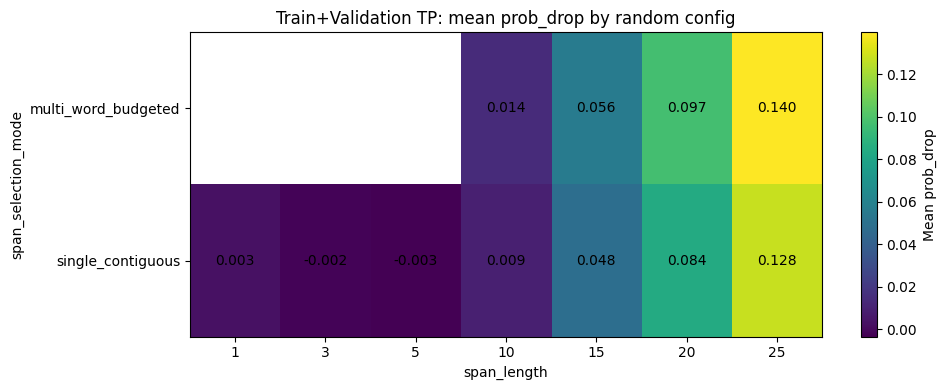

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/plots/random_train_val_tp_heatmap_mean_prob_drop.png


span_length,1,3,5,10,15,20,25
span_selection_mode,,,,,,,
multi_word_budgeted,NaN,NaN,NaN,0.014109,0.056117,0.096632,0.139608
single_contiguous,0.002912,-0.001732,-0.003359,0.009283,0.048302,0.084050,0.127648


In [26]:
heatmap_df = val_tp_config_summary.copy()
heatmap_df = heatmap_df[heatmap_df["ablation_mode"] == "mask"].copy()

heatmap_data = heatmap_df.pivot(
    index="span_selection_mode",
    columns="span_length",
    values="mean_prob_drop"
)

plt.figure(figsize=(10, 4))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Mean prob_drop")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)
plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

for y_idx, selection_mode in enumerate(heatmap_data.index):
    for x_idx, span_length in enumerate(heatmap_data.columns):
        value = heatmap_data.loc[selection_mode, span_length]
        if pd.notna(value):
            plt.text(
                x_idx,
                y_idx,
                f"{value:.3f}",
                ha="center",
                va="center"
            )

plt.xlabel("span_length")
plt.ylabel("span_selection_mode")
plt.title("Train+Validation TP: mean prob_drop by random config")
plt.tight_layout()

plot_path = PLOTS_DIR / "random_train_val_tp_heatmap_mean_prob_drop.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)
display(heatmap_data)

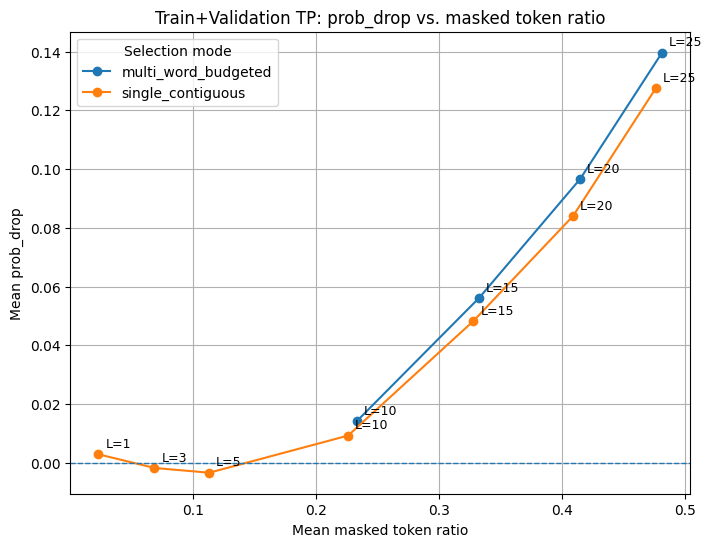

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/plots/random_train_val_tp_prob_drop_vs_masked_token_ratio.png


In [27]:
plot_df = val_tp_config_summary.copy()
plot_df = plot_df[plot_df["ablation_mode"] == "mask"].copy()

plt.figure(figsize=(8, 6))

for selection_mode in sorted(plot_df["span_selection_mode"].unique()):
    subset = (
        plot_df[plot_df["span_selection_mode"] == selection_mode]
        .sort_values("mean_masked_token_ratio")
        .copy()
    )
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        marker="o",
        label=selection_mode
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"L={int(row['span_length'])}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean prob_drop")
plt.title("Train+Validation TP: prob_drop vs. masked token ratio")
plt.grid(True)
plt.legend(title="Selection mode")

plot_path = PLOTS_DIR / "random_train_val_tp_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

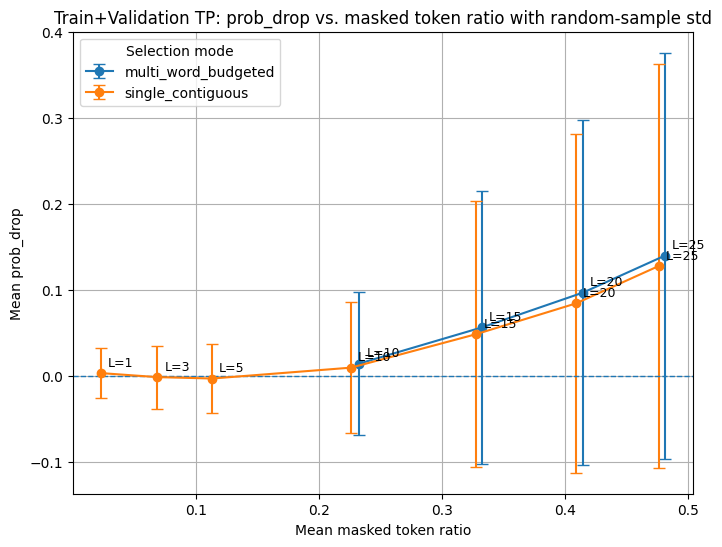

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/plots/random_train_val_tp_prob_drop_vs_masked_token_ratio_with_sample_std.png


In [28]:
plot_df = val_tp_config_summary.copy()
plot_df = plot_df[plot_df["ablation_mode"] == "mask"].copy()

plt.figure(figsize=(8, 6))

for selection_mode in sorted(plot_df["span_selection_mode"].unique()):
    subset = (
        plot_df[plot_df["span_selection_mode"] == selection_mode]
        .sort_values("mean_masked_token_ratio")
        .copy()
    )
    
    plt.errorbar(
        subset["mean_masked_token_ratio"],
        subset["mean_prob_drop"],
        # xerr=subset["mean_masked_token_ratio"],
        yerr=subset["std_argument_mean_prob_drop"],
        marker="o",
        capsize=4,
        label=selection_mode
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"L={int(row['span_length'])}",
            (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean prob_drop")
plt.title("Train+Validation TP: prob_drop vs. masked token ratio with random-sample std")
plt.grid(True)
plt.legend(title="Selection mode")

plot_path = PLOTS_DIR / "random_train_val_tp_prob_drop_vs_masked_token_ratio_with_sample_std.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

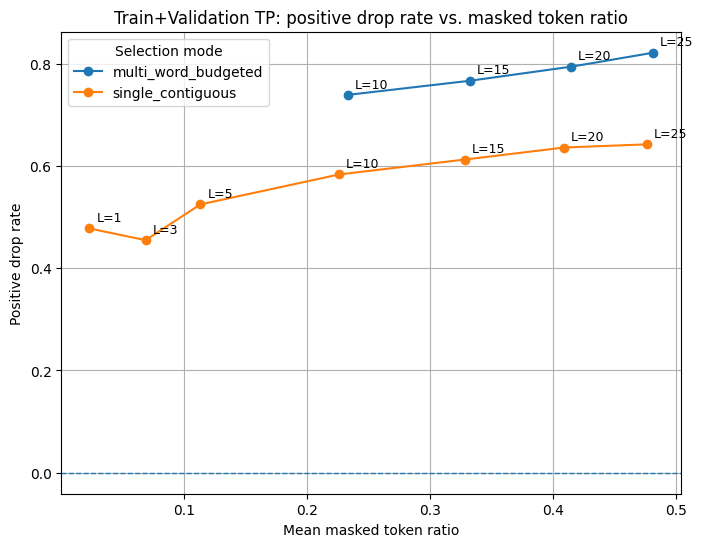

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/plots/random_train_val_tp_positive_drop_rate_vs_masked_token_ratio.png


In [29]:
plot_df = val_tp_config_summary.copy()
plot_df = plot_df[plot_df["ablation_mode"] == "mask"].copy()

plt.figure(figsize=(8, 6))

for selection_mode in sorted(plot_df["span_selection_mode"].unique()):
    subset = (
        plot_df[plot_df["span_selection_mode"] == selection_mode]
        .sort_values("mean_masked_token_ratio")
        .copy()
    )
    
    plt.plot(
        subset["mean_masked_token_ratio"],
        subset["positive_drop_rate"],
        marker="o",
        label=selection_mode
    )
    
    for _, row in subset.iterrows():
        plt.annotate(
            f"L={int(row['span_length'])}",
            (row["mean_masked_token_ratio"], row["positive_drop_rate"]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Mean masked token ratio")
plt.ylabel("Positive drop rate")
plt.title("Train+Validation TP: positive drop rate vs. masked token ratio")
plt.grid(True)
plt.legend(title="Selection mode")

plot_path = PLOTS_DIR / "random_train_val_tp_positive_drop_rate_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [30]:
# -------------------------------------------------------------------
# Rank random baseline configs on train+validation true positives.
# -------------------------------------------------------------------
# This ranking is only a decision aid. The final BEST_* variables are set
# manually in the next cell after inspecting the plots and summaries.

ranked_train_val_configs = val_tp_config_summary.copy()
ranked_train_val_configs = ranked_train_val_configs[
    ranked_train_val_configs["ablation_mode"] == "mask"
].copy()

ranked_train_val_configs["has_positive_mean_drop"] = (
    ranked_train_val_configs["mean_prob_drop"] > 0
)

ranked_train_val_configs = (
    ranked_train_val_configs
    .sort_values(
        [
            "has_positive_mean_drop",
            "drop_per_masked_token_ratio",
            "mean_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_001",
            "mean_masked_token_ratio"
        ],
        ascending=[False, False, False, False, False, True]
    )
    .reset_index(drop=True)
)

display(
    ranked_train_val_configs[
        [
            "span_selection_mode",
            "span_length",
            "ablation_mode",
            "n_arguments",
            "mean_prob_drop",
            "std_argument_mean_prob_drop",
            "mean_sample_std_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_001",
            "mean_masked_token_ratio",
            "mean_sample_std_masked_token_ratio",
            "drop_per_masked_token_ratio",
            "mean_n_merged_spans"
        ]
    ]
)

ranked_train_val_configs.to_csv(
    config_search_ranked_path,
    index=False,
    encoding="utf-8"
)

print("Saved:", config_search_ranked_path)

,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,std_argument_mean_prob_drop,mean_sample_std_prob_drop,positive_drop_rate,strong_drop_rate_001,mean_masked_token_ratio,mean_sample_std_masked_token_ratio,drop_per_masked_token_ratio,mean_n_merged_spans
0,multi_word_budgeted,25,mask,873,0.139608,0.236084,0.035299,0.821306,0.305155,0.481007,0.018327,0.290242,13.472165
1,single_contiguous,25,mask,873,0.127648,0.235192,0.027688,0.642153,0.258877,0.476195,0.014582,0.268058,1.000000
2,multi_word_budgeted,20,mask,873,0.096632,0.201085,0.032385,0.794044,0.244215,0.414540,0.020189,0.233107,12.114089
3,single_contiguous,20,mask,873,0.084050,0.197011,0.024710,0.635968,0.203895,0.408841,0.016182,0.205581,1.000000
4,multi_word_budgeted,15,mask,873,0.056117,0.158755,0.027302,0.766552,0.164032,0.332405,0.022982,0.168823,10.293242
5,single_contiguous,15,mask,873,0.048302,0.154469,0.021371,0.612371,0.128981,0.327859,0.018007,0.147326,1.000000
6,single_contiguous,1,mask,873,0.002912,0.028882,0.010676,0.477663,0.030241,0.023168,0.007429,0.125677,1.000000
7,multi_word_budgeted,10,mask,873,0.014109,0.082993,0.018246,0.738832,0.089118,0.232906,0.024527,0.060576,7.931501
8,single_contiguous,10,mask,873,0.009283,0.076070,0.013513,0.583276,0.058877,0.226032,0.019565,0.041071,1.000000
9,single_contiguous,3,mask,873,-0.001732,0.036665,0.008644,0.454754,0.014204,0.068762,0.015091,-0.025184,1.000000


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_train_val_tp_ranked_configs.csv


In [31]:
# -------------------------------------------------------------------
# Manually set the selected random baseline config.
# -------------------------------------------------------------------
# Choose these values after inspecting:
# - random_train_val_tp_config_summary.csv
# - random_train_val_tp_ranked_configs.csv
# - prob_drop vs. masked_token_ratio plots

BEST_SPAN_SELECTION_MODE = "multi_word_budgeted"
BEST_SPAN_LENGTH = 25
BEST_ABLATION_MODE = "mask"

assert BEST_ABLATION_MODE == "mask"
assert BEST_SPAN_SELECTION_MODE in SPAN_SELECTION_MODES
assert BEST_SPAN_LENGTH in SPAN_LENGTH_VALUES

selected_config = {
    "span_selection_mode": BEST_SPAN_SELECTION_MODE,
    "span_length": BEST_SPAN_LENGTH,
    "ablation_mode": BEST_ABLATION_MODE,
    "selection_basis": CONFIG_SEARCH_SCOPE,
    "n_random_samples_per_config": N_RANDOM_SAMPLES_PER_CONFIG
}

with open(OUTPUT_DIR / "random_selected_config_manual.json", "w", encoding="utf-8") as f:
    json.dump(
        make_json_serializable(selected_config),
        f,
        ensure_ascii=False,
        indent=2
    )

print("Selected config:")
print(selected_config)

Selected config:
{'span_selection_mode': 'multi_word_budgeted', 'span_length': 25, 'ablation_mode': 'mask', 'selection_basis': 'train_val_tp', 'n_random_samples_per_config': 5}


In [32]:
# -------------------------------------------------------------------
# Phase 2: apply selected best config to all splits.
# -------------------------------------------------------------------
# For completeness, the selected config is applied to train, validation, and test.
# Final reporting should focus on the test split, especially test true positives.

BEST_SPAN_LENGTH_VALUES = [BEST_SPAN_LENGTH]
BEST_ABLATION_MODES = [BEST_ABLATION_MODE]
BEST_SELECTION_MODES = [BEST_SPAN_SELECTION_MODE]
N_RANDOM_SAMPLES_PER_CONFIG = 1

train_results, train_argument_df, train_span_df = run_random_baseline_on_split(
    df=train_df,
    split_name="train_best_config",
    matrix_positions=None,
    span_length_values=BEST_SPAN_LENGTH_VALUES,
    ablation_modes=BEST_ABLATION_MODES,
    selection_modes=BEST_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG
)

val_results, val_argument_df, val_span_df = run_random_baseline_on_split(
    df=val_df,
    split_name="validation_best_config",
    matrix_positions=None,
    span_length_values=BEST_SPAN_LENGTH_VALUES,
    ablation_modes=BEST_ABLATION_MODES,
    selection_modes=BEST_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG
)

test_results, test_argument_df, test_span_df = run_random_baseline_on_split(
    df=test_df,
    split_name="test_best_config",
    matrix_positions=None,
    span_length_values=BEST_SPAN_LENGTH_VALUES,
    ablation_modes=BEST_ABLATION_MODES,
    selection_modes=BEST_SELECTION_MODES,
    n_random_samples=N_RANDOM_SAMPLES_PER_CONFIG
)

final_argument_df = pd.concat(
    [train_argument_df, val_argument_df, test_argument_df],
    ignore_index=True
)

final_span_df = pd.concat(
    [train_span_df, val_span_df, test_span_df],
    ignore_index=True
)

final_argument_df["eval_scope"] = "best_config_all_splits"
final_span_df["eval_scope"] = "best_config_all_splits"

all_results = train_results + val_results + test_results

display(final_argument_df.head())
display(final_span_df.head())

print("Final best-config argument-level sample rows:", len(final_argument_df))
print("Final best-config span-level sample rows:", len(final_span_df))
print("Unique arguments:", final_argument_df["global_row_id"].nunique())

save_random_outputs(
    argument_df=final_argument_df,
    span_df=final_span_df,
    results=all_results,
    prefix="random_best_config_all_splits"
)

Building random spans:   0%|          | 0/1533 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/96 [00:00<?, ?it/s]

train_best_config argument level: (1533, 52)
train_best_config span level: (22264, 49)


Building random spans:   0%|          | 0/220 [00:00<?, ?it/s]

Classifier inference:   0%|          | 0/14 [00:00<?, ?it/s]

...

test_best_config argument level: (438, 52)
test_best_config span level: (6401, 49)


,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,merged_span_char_end_indices,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error,eval_scope
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[46, 105, 113, 121, 143, 166]","[""people"", "" cant"", "" be"", "" forced"", "" to"", ""...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 46, ""word_start...",False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[4, 42, 93, 124, 142, 149, 164, 182, 214, 235,...","[""That"", "" forum,"", "" lowest"", "" denominator.""...","[""▁That"", ""▁forum"", "","", ""▁lowest"", ""▁denomina...","[{""char_start"": 0, ""char_end"": 4, ""word_start_...",False,"That form of argument degrades this forum, and...",[MASK] form of argument degrades this [MASK] [...,[MASK] form of argument degrades this [MASK] [...,None,best_config_all_splits
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[18, 29, 45, 80, 121, 139, 166]","[""I"", "" wouldnt"", "" turn"", "" her"", "" becuase"",...","[""▁I"", ""▁wouldnt"", ""▁turn"", ""▁her"", ""▁becuase""...","[{""char_start"": 0, ""char_end"": 18, ""word_start...",False,I wouldnt turn her in becuase she is my wife. ...,[MASK] [MASK] [MASK] [MASK] in [MASK] she is [...,[MASK] [MASK] [MASK] [MASK] in [MASK] she is [...,None,best_config_all_splits
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,[143],"[""No"", "" I"", "" wouldn't"", "" turn"", "" in"", "" my...","[""▁No"", ""▁I"", ""▁wouldn"", ""'"", ""t"", ""▁turn"", ""▁...","[{""char_start"": 0, ""char_end"": 143, ""word_star...",False,No I wouldn't turn in my spouse. Just because ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,"[123, 142, 151]","[""TV"", "" is"", "" terrible."", "" Except"", "" for"",...","[""▁TV"", ""▁is"", ""▁terrible"", ""."", ""▁Except"", ""▁...","[{""char_start"": 0, ""char_end"": 123, ""word_star...",False,TV is terrible. Except for Spongebob maybe. Th...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits


,global_row_id,split,post_id,issue,label,predicted_label,confusion_type,is_true_positive,is_false_negative,is_false_positive,...,n_selected_tokens,n_selected_words,selected_token_ratio,selected_word_ratio,masked_token_ratio,was_truncated,text,perturbed_text,masked_text,eval_scope
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,29,25,0.690476,0.657895,0.690476,False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,best_config_all_splits
1,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,29,25,0.690476,0.657895,0.690476,False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,best_config_all_splits
2,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,29,25,0.690476,0.657895,0.690476,False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,best_config_all_splits
3,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,29,25,0.690476,0.657895,0.690476,False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,best_config_all_splits
4,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,TP,True,False,False,...,29,25,0.690476,0.657895,0.690476,False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,best_config_all_splits


Final best-config argument-level sample rows: 2191
Final best-config span-level sample rows: 31887
Unique arguments: 2191
Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_argument_level_samples.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_span_level_samples.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_argument_level_samples.jsonl


{'argument_csv_path': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_argument_level_samples.csv'),
 'span_csv_path': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_span_level_samples.csv'),
 'jsonl_path': PosixPath('/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_all_splits_argument_level_samples.jsonl')}

In [33]:
# -------------------------------------------------------------------
# Final summaries for selected best config.
# -------------------------------------------------------------------

final_argument_df_valid = final_argument_df[
    final_argument_df["error"].isna()
].copy()

final_argument_df_valid = final_argument_df_valid.dropna(
    subset=["prob_drop"]
).copy()

# Sanity check: after Phase 2, each argument should have exactly one random sample
# because the selected config is evaluated with n_random_samples=1.
sample_counts = (
    final_argument_df_valid
    .groupby(["split", "global_row_id"])
    ["sample_id"]
    .nunique()
    .reset_index(name="n_random_samples")
)

display(sample_counts["n_random_samples"].value_counts())

if sample_counts["n_random_samples"].max() > 1:
    print(
        "Warning: Some arguments have more than one random sample. "
        "Check whether Phase 2 was really run with n_random_samples=1."
    )

# Since there is exactly one final sample per argument, this file is both:
# - the final sample-level output
# - the final per-argument output with concrete spans
final_per_argument_df = final_argument_df_valid.copy()

final_per_argument_df["final_selection_type"] = (
    "single_random_sample_with_validation_selected_config"
)

display(final_per_argument_df.head())

print("Final valid rows:", len(final_per_argument_df))
print("Unique arguments:", final_per_argument_df["global_row_id"].nunique())

n_random_samples
1    2191
Name: count, dtype: int64

,global_row_id,split,post_id,issue,label,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,...,selected_words_json,selected_tokens_json,merged_spans_json,was_truncated,text,perturbed_text,masked_text,error,eval_scope,final_selection_type
0,0,train,1,Is the school uniform a good or bad idea:,1,LABEL_1,0.997032,TP,True,False,...,"[""people"", "" cant"", "" be"", "" forced"", "" to"", ""...","[""▁people"", ""▁can"", ""t"", ""▁be"", ""▁forced"", ""▁t...","[{""char_start"": 0, ""char_end"": 46, ""word_start...",False,"people cant be forced to wear school uniforms,...",[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits,single_random_sample_with_validation_selected_...
1,1,train,2,Firefox vs internet explorer:,1,LABEL_1,0.998218,TP,True,False,...,"[""That"", "" forum,"", "" lowest"", "" denominator.""...","[""▁That"", ""▁forum"", "","", ""▁lowest"", ""▁denomina...","[{""char_start"": 0, ""char_end"": 4, ""word_start_...",False,"That form of argument degrades this forum, and...",[MASK] form of argument degrades this [MASK] [...,[MASK] form of argument degrades this [MASK] [...,None,best_config_all_splits,single_random_sample_with_validation_selected_...
2,2,train,3,If your spouse committed murder and he or she ...,0,LABEL_0,0.969683,TN,False,False,...,"[""I"", "" wouldnt"", "" turn"", "" her"", "" becuase"",...","[""▁I"", ""▁wouldnt"", ""▁turn"", ""▁her"", ""▁becuase""...","[{""char_start"": 0, ""char_end"": 18, ""word_start...",False,I wouldnt turn her in becuase she is my wife. ...,[MASK] [MASK] [MASK] [MASK] in [MASK] she is [...,[MASK] [MASK] [MASK] [MASK] in [MASK] she is [...,None,best_config_all_splits,single_random_sample_with_validation_selected_...
3,3,train,4,If your spouse committed murder and he or she ...,1,LABEL_1,0.998705,TP,True,False,...,"[""No"", "" I"", "" wouldn't"", "" turn"", "" in"", "" my...","[""▁No"", ""▁I"", ""▁wouldn"", ""'"", ""t"", ""▁turn"", ""▁...","[{""char_start"": 0, ""char_end"": 143, ""word_star...",False,No I wouldn't turn in my spouse. Just because ...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits,single_random_sample_with_validation_selected_...
4,4,train,5,Tv is better than books:,1,LABEL_1,0.998405,TP,True,False,...,"[""TV"", "" is"", "" terrible."", "" Except"", "" for"",...","[""▁TV"", ""▁is"", ""▁terrible"", ""."", ""▁Except"", ""▁...","[{""char_start"": 0, ""char_end"": 123, ""word_star...",False,TV is terrible. Except for Spongebob maybe. Th...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MAS...,None,best_config_all_splits,single_random_sample_with_validation_selected_...


Final valid rows: 2191
Unique arguments: 2191


In [34]:
# -------------------------------------------------------------------
# Aggregate final results by split and confusion type.
# -------------------------------------------------------------------
# Because Phase 2 uses one sample per argument, these summaries aggregate
# directly over arguments.

final_split_summary = (
    final_per_argument_df
    .groupby(
        [
            "split",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        min_prob_drop=("prob_drop", "min"),
        max_prob_drop=("prob_drop", "max"),
        positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
        strong_drop_rate_001=("prob_drop", lambda x: float((x > 0.01).mean())),
        strong_drop_rate_005=("prob_drop", lambda x: float((x > 0.05).mean())),
        mean_p_inappropriate_original=("p_inappropriate_original", "mean"),
        mean_p_inappropriate_masked=("p_inappropriate_masked", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        std_masked_token_ratio=("masked_token_ratio", "std"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean"),
        mean_total_masked_chars=("total_masked_chars", "mean"),
        truncation_rate=("was_truncated", lambda x: float(x.mean()))
    )
    .sort_values(["split"])
)

final_split_summary["drop_per_masked_token_ratio"] = (
    final_split_summary["mean_prob_drop"]
    / final_split_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

final_confusion_summary = (
    final_per_argument_df
    .groupby(
        [
            "split",
            "confusion_type",
            "span_selection_mode",
            "span_length",
            "ablation_mode"
        ],
        as_index=False
    )
    .agg(
        n_arguments=("global_row_id", "nunique"),
        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),
        min_prob_drop=("prob_drop", "min"),
        max_prob_drop=("prob_drop", "max"),
        positive_drop_rate=("prob_drop", lambda x: float((x > 0).mean())),
        strong_drop_rate_001=("prob_drop", lambda x: float((x > 0.01).mean())),
        strong_drop_rate_005=("prob_drop", lambda x: float((x > 0.05).mean())),
        mean_p_inappropriate_original=("p_inappropriate_original", "mean"),
        mean_p_inappropriate_masked=("p_inappropriate_masked", "mean"),
        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        std_masked_token_ratio=("masked_token_ratio", "std"),
        mean_n_merged_spans=("n_merged_spans", "mean"),
        mean_total_masked_tokens=("total_masked_tokens", "mean")
    )
    .sort_values(
        [
            "split",
            "confusion_type"
        ]
    )
)

final_confusion_summary["drop_per_masked_token_ratio"] = (
    final_confusion_summary["mean_prob_drop"]
    / final_confusion_summary["mean_masked_token_ratio"].replace(0, np.nan)
)

display(final_split_summary)
display(final_confusion_summary)

,split,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,min_prob_drop,max_prob_drop,...,strong_drop_rate_005,mean_p_inappropriate_original,mean_p_inappropriate_masked,mean_masked_token_ratio,std_masked_token_ratio,mean_n_merged_spans,mean_total_masked_tokens,mean_total_masked_chars,truncation_rate,drop_per_masked_token_ratio
0,test,multi_word_budgeted,25,mask,438,-0.102502,-0.000170,0.434738,-0.993135,0.940539,...,0.164384,0.590803,0.693305,0.431684,0.280245,14.614155,29.098174,118.787671,0.0,-0.237448
1,train,multi_word_budgeted,25,mask,1533,-0.109492,-0.000144,0.430587,-0.995784,0.934867,...,0.161122,0.552140,0.661632,0.439278,0.286566,14.523157,29.329419,119.165036,0.0,-0.249254
2,validation,multi_word_budgeted,25,mask,220,-0.141181,-0.002078,0.452649,-0.995371,0.672921,...,0.145455,0.542073,0.683255,0.425503,0.281992,14.645455,28.545455,118.745455,0.0,-0.331799


,split,confusion_type,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,min_prob_drop,...,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_inappropriate_original,mean_p_inappropriate_masked,mean_masked_token_ratio,std_masked_token_ratio,mean_n_merged_spans,mean_total_masked_tokens,drop_per_masked_token_ratio
0,test,FN,multi_word_budgeted,25,mask,39,-0.410125,-0.252954,0.415706,-0.987972,...,0.102564,0.051282,0.025641,0.049637,0.459762,0.363480,0.259844,16.307692,28.410256,-1.128327
1,test,FP,multi_word_budgeted,25,mask,71,0.135861,0.000761,0.279141,-0.370698,...,0.690141,0.352113,0.281690,0.971583,0.835722,0.495157,0.311481,13.042254,28.577465,0.274380
2,test,TN,multi_word_budgeted,25,mask,142,-0.438700,-0.258011,0.421522,-0.993135,...,0.049296,0.035211,0.021127,0.037214,0.475915,0.328128,0.170148,17.035211,29.295775,-1.336980
3,test,TP,multi_word_budgeted,25,mask,186,0.127678,0.000820,0.253494,-0.358659,...,0.833333,0.290323,0.258065,0.981553,0.853876,0.500816,0.311946,13.010753,29.290323,0.254940
4,train,FN,multi_word_budgeted,25,mask,48,-0.431323,-0.354671,0.438894,-0.991041,...,0.187500,0.187500,0.145833,0.115294,0.546616,0.444847,0.260235,14.250000,28.604167,-0.969597
5,train,FP,multi_word_budgeted,25,mask,48,0.071983,0.000337,0.309283,-0.468885,...,0.541667,0.291667,0.270833,0.915787,0.843803,0.532686,0.317951,11.958333,28.520833,0.135133
6,train,TN,multi_word_budgeted,25,mask,652,-0.400280,-0.223323,0.411547,-0.995784,...,0.075153,0.052147,0.016871,0.030158,0.430438,0.381108,0.240507,15.915644,28.917178,-1.050306
7,train,TP,multi_word_budgeted,25,mask,785,0.140611,0.000779,0.251130,-0.363978,...,0.828025,0.308280,0.275159,0.990161,0.849549,0.481540,0.311735,13.540127,29.765605,0.292003
8,validation,FN,multi_word_budgeted,25,mask,36,-0.513410,-0.642393,0.444245,-0.991080,...,0.083333,0.083333,0.027778,0.040577,0.553988,0.344278,0.242960,16.666667,27.750000,-1.491266
9,validation,FP,multi_word_budgeted,25,mask,30,0.129835,0.000479,0.259813,-0.231427,...,0.566667,0.300000,0.300000,0.968821,0.838986,0.471890,0.303830,13.433333,28.000000,0.275138


In [35]:
# -------------------------------------------------------------------
# Save final selected-config results.
# -------------------------------------------------------------------

final_per_argument_path = (
    OUTPUT_DIR / "random_best_config_per_argument.csv"
)

final_split_summary_path = (
    OUTPUT_DIR / "random_best_config_split_summary.csv"
)

final_confusion_summary_path = (
    OUTPUT_DIR / "random_best_config_confusion_summary.csv"
)

final_test_per_argument_path = (
    OUTPUT_DIR / "random_best_config_test_per_argument.csv"
)

final_test_tp_per_argument_path = (
    OUTPUT_DIR / "random_best_config_test_tp_per_argument.csv"
)

final_per_argument_df.to_csv(
    final_per_argument_path,
    index=False,
    encoding="utf-8"
)

final_split_summary.to_csv(
    final_split_summary_path,
    index=False,
    encoding="utf-8"
)

final_confusion_summary.to_csv(
    final_confusion_summary_path,
    index=False,
    encoding="utf-8"
)

final_test_per_argument_df = (
    final_per_argument_df
    .loc[final_per_argument_df["split"] == "test"]
    .copy()
    .reset_index(drop=True)
)

final_test_tp_per_argument_df = (
    final_per_argument_df
    .loc[
        (final_per_argument_df["split"] == "test") &
        (final_per_argument_df["confusion_type"] == "TP")
    ]
    .copy()
    .reset_index(drop=True)
)

final_test_per_argument_df.to_csv(
    final_test_per_argument_path,
    index=False,
    encoding="utf-8"
)

final_test_tp_per_argument_df.to_csv(
    final_test_tp_per_argument_path,
    index=False,
    encoding="utf-8"
)

print("Saved:")
print(final_per_argument_path)
print(final_split_summary_path)
print(final_confusion_summary_path)
print(final_test_per_argument_path)
print(final_test_tp_per_argument_path)

Saved:
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_per_argument.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_split_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_confusion_summary.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_test_per_argument.csv
/Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/random_best_config_test_tp_per_argument.csv


,split,confusion_type,span_selection_mode,span_length,ablation_mode,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,min_prob_drop,...,positive_drop_rate,strong_drop_rate_001,strong_drop_rate_005,mean_p_inappropriate_original,mean_p_inappropriate_masked,mean_masked_token_ratio,std_masked_token_ratio,mean_n_merged_spans,mean_total_masked_tokens,drop_per_masked_token_ratio
3,test,TP,multi_word_budgeted,25,mask,186,0.127678,0.00082,0.253494,-0.358659,...,0.833333,0.290323,0.258065,0.981553,0.853876,0.500816,0.311946,13.010753,29.290323,0.25494


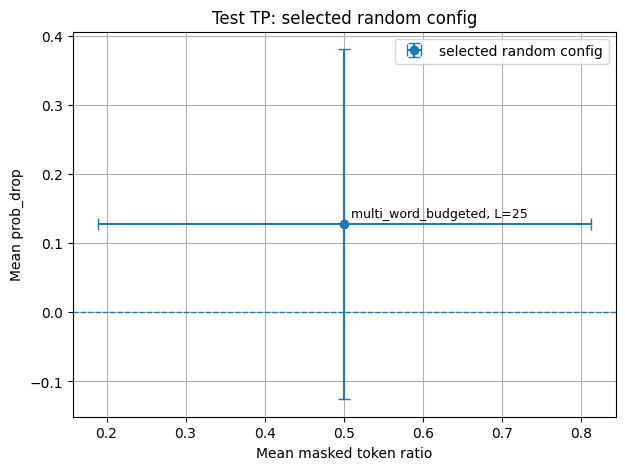

Saved plot: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/random_baseline_results_multi_mask/plots/random_test_tp_selected_config_prob_drop_vs_masked_token_ratio.png


In [36]:
# -------------------------------------------------------------------
# Final test diagnostic for the selected random config.
# -------------------------------------------------------------------
# Since the final phase uses one random sample per argument, the error bars
# visualize variation across test arguments, not variation across random samples.

test_tp_final_summary = (
    final_confusion_summary
    .loc[
        (final_confusion_summary["split"] == "test") &
        (final_confusion_summary["confusion_type"] == "TP")
    ]
    .copy()
)

display(test_tp_final_summary)

plt.figure(figsize=(7, 5))

plt.errorbar(
    test_tp_final_summary["mean_masked_token_ratio"],
    test_tp_final_summary["mean_prob_drop"],
    xerr=test_tp_final_summary["std_masked_token_ratio"],
    yerr=test_tp_final_summary["std_prob_drop"],
    marker="o",
    capsize=4,
    linestyle="None",
    label="selected random config"
)

for _, row in test_tp_final_summary.iterrows():
    label = (
        f"{row['span_selection_mode']}, "
        f"L={int(row['span_length'])}"
    )
    plt.annotate(
        label,
        (row["mean_masked_token_ratio"], row["mean_prob_drop"]),
        textcoords="offset points",
        xytext=(5, 5),
        fontsize=9
    )

plt.axhline(0.0, linestyle="--", linewidth=1)
plt.xlabel("Mean masked token ratio")
plt.ylabel("Mean prob_drop")
plt.title("Test TP: selected random config")
plt.grid(True)
plt.legend()

plot_path = PLOTS_DIR / "random_test_tp_selected_config_prob_drop_vs_masked_token_ratio.png"
plt.savefig(plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot:", plot_path)

In [37]:
def show_random_example(result_df, index=0):
    """Display one random baseline result with highlighted perturbed spans."""
    row = result_df.iloc[index]
    
    spans = json.loads(row["merged_spans_json"])
    marked = highlight_spans(row["text"], spans)
    
    display(HTML(f"""
    <div style="
        border:1px solid #ccc;
        border-radius:8px;
        padding:14px;
        margin:12px 0;
        font-family:Arial, sans-serif;
        line-height:1.45;
    ">
        <b>global_row_id:</b> {html.escape(str(row["global_row_id"]))}<br>
        <b>post_id:</b> {html.escape(str(row["post_id"]))}<br>
        <b>split:</b> {html.escape(str(row["split"]))}<br>
        <b>confusion_type:</b> {html.escape(str(row["confusion_type"]))}<br>
        <b>issue:</b> {html.escape(str(row["issue"]))}<br>
        <b>method:</b> {html.escape(str(row["attribution_method"]))}<br>
        <b>selection_mode:</b> {html.escape(str(row["span_selection_mode"]))} |
        <b>span_length:</b> {html.escape(str(row["span_length"]))} |
        <b>sample_id:</b> {html.escape(str(row["sample_id"]))} |
        <b>ablation_mode:</b> {html.escape(str(row["ablation_mode"]))}<br>
        <b>merged_spans:</b> {html.escape(str(row["merged_span_texts"]))}<br>
        <b>p_original:</b> {float(row["p_inappropriate_original"]):.4f}<br>
        <b>p_perturbed:</b> {float(row["p_inappropriate_perturbed"]):.4f}<br>
        <b>prob_drop:</b> {float(row["prob_drop"]):.4f}<br>
        <b>masked_token_ratio:</b> {float(row["masked_token_ratio"]):.4f}<br>
        <hr>
        <b>Original with highlighted random span(s):</b><br>
        <div style="margin-top:6px;">{marked}</div>
        <hr>
        <b>Perturbed text:</b><br>
        <div style="margin-top:6px; color:#555;">
            {html.escape(str(row["perturbed_text"]))}
        </div>
    </div>
    """))

In [38]:
# -------------------------------------------------------------------
# Show strongest final random baseline examples on the test set.
# -------------------------------------------------------------------
# These are not oracle-selected from multiple random samples.
# They are simply the highest-prob_drop examples among the single final random draw.

test_best_examples = (
    final_test_per_argument_df
    .sort_values("prob_drop", ascending=False)
    .reset_index(drop=True)
)

print("Best test examples from selected random config:")

for i in range(min(5, len(test_best_examples))):
    show_random_example(test_best_examples, index=i)

Best test examples from selected random config:


In [39]:
# -------------------------------------------------------------------
# Show weakest final random baseline examples on the test set.
# -------------------------------------------------------------------

test_low_examples = (
    final_test_per_argument_df
    .sort_values("prob_drop", ascending=True)
    .reset_index(drop=True)
)

print("Least helpful test examples from selected random config:")

for i in range(min(5, len(test_low_examples))):
    show_random_example(test_low_examples, index=i)

Least helpful test examples from selected random config:


## Final random baseline evaluation

The final random baseline uses the configuration selected from train+validation true positives. In contrast to the config-search phase, the final phase uses only one random sample per argument. This avoids an oracle-style best-of-five selection and provides exactly one concrete random span selection per argument.

The final per-argument file can therefore be used directly for span-level overlap evaluation, because each row corresponds to one argument and one concrete masked span selection.

The reported standard deviations in the final summaries describe variation across arguments. Random-sample variation was only estimated during config search, where each configuration was sampled multiple times per argument.